# Building a Quant Trading Strategy

## Part 1: Build a ML Model in PyTorch for QQQ

In [184]:
# y_hat = model(x)
# orders = strategy(y_hat)
# execute(orders)

In [107]:
# regression model => QQQ => future log return

In [108]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random

# Machine learning libraries
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities

# Visualization
import altair as alt                        # Interactive visualization library

# Data source for QQQ (stock ETF)
import yfinance as yf                       # Yahoo Finance market data

In [109]:
import altair as alt
print(alt.__version__)

6.0.0


In [110]:
research.set_seed(42)

In [111]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [112]:
# Trading symbol
sym = 'QQQ'
# time horizon of time series (daily bars for stock ETF)
time_interval = '1d'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps
forecast_horizon = 1
# Sharpe annualized rate for stocks (252 trading days, ~6.5 hours/day)
annualized_rate = research.sharpe_annualization_factor(time_interval, 252, 6.5)

In [113]:
# Download QQQ daily OHLC data from Yahoo Finance
start_date = datetime(2023, 10, 29)
end_date = datetime(2025, 10, 9)

qqq_data = yf.download(sym, start=start_date, end=end_date, interval='1d')
qqq_data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2023-10-30,344.081879,345.402235,341.372185,342.731933,55298500
2023-10-31,345.727386,346.101822,341.539678,344.111439,47671900
2023-11-01,351.728119,352.289772,346.466390,346.564930,58992700
2023-11-02,358.113129,358.349601,355.019137,356.240983,58162400
2023-11-03,362.320496,363.611293,359.177249,359.403889,53280500


In [114]:
# Convert Yahoo Finance pandas DataFrame to Polars DataFrame
# Match the format expected by research module (datetime, open, high, low, close)
ts = pl.DataFrame({
    'datetime': qqq_data.index.to_pydatetime().tolist(),
    'open': qqq_data['Open'].values.flatten().astype(float),
    'high': qqq_data['High'].values.flatten().astype(float),
    'low': qqq_data['Low'].values.flatten().astype(float),
    'close': qqq_data['Close'].values.flatten().astype(float),
}).with_columns(pl.col('datetime').cast(pl.Datetime))
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2023-10-30 00:00:00,342.731933,345.402235,341.372185,344.081879
2023-10-31 00:00:00,344.111439,346.101822,341.539678,345.727386
2023-11-01 00:00:00,346.56493,352.289772,346.46639,351.728119
2023-11-02 00:00:00,356.240983,358.349601,355.019137,358.113129
2023-11-03 00:00:00,359.403889,363.611293,359.177249,362.320496
…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696


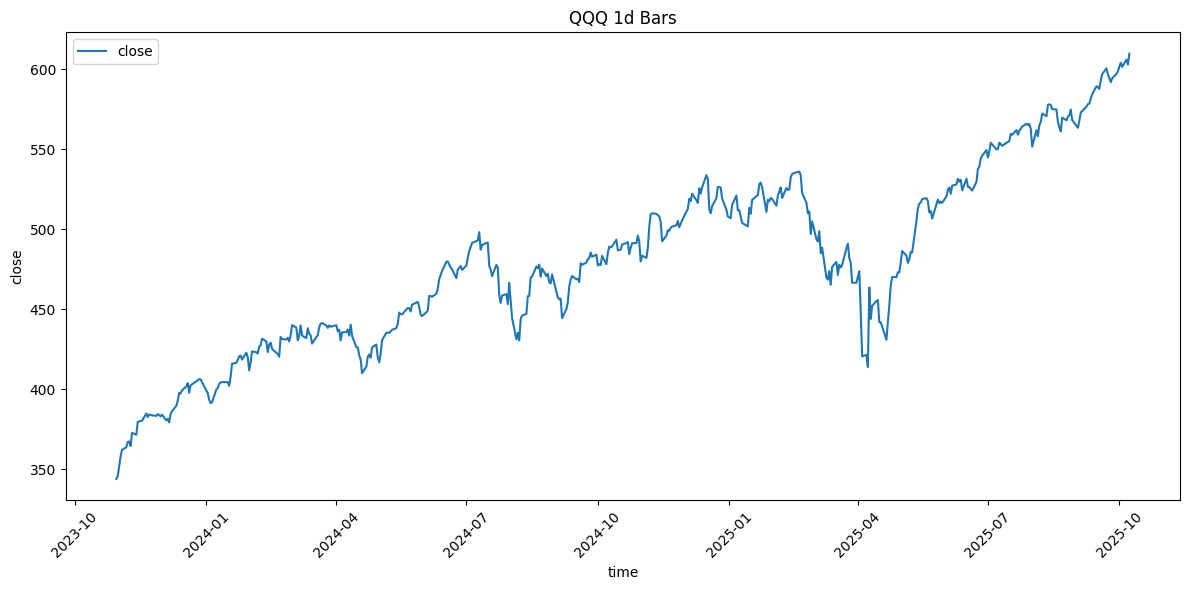

In [115]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [116]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [117]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [118]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [119]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2023-10-30 00:00:00,342.731933,345.402235,341.372185,344.081879,null
2023-10-31 00:00:00,344.111439,346.101822,341.539678,345.727386,0.004771
2023-11-01 00:00:00,346.56493,352.289772,346.46639,351.728119,0.017208
2023-11-02 00:00:00,356.240983,358.349601,355.019137,358.113129,0.01799
2023-11-03 00:00:00,359.403889,363.611293,359.177249,362.320496,0.01168
…,…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721,0.004103
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264,-0.004219
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696,0.007482


In [120]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,342.731933,345.402235,341.372185,344.081879,null,null,null,null,null
2023-10-31 00:00:00,344.111439,346.101822,341.539678,345.727386,0.004771,null,null,null,null
2023-11-01 00:00:00,346.56493,352.289772,346.46639,351.728119,0.017208,0.004771,null,null,null
2023-11-02 00:00:00,356.240983,358.349601,355.019137,358.113129,0.01799,0.017208,0.004771,null,null
2023-11-03 00:00:00,359.403889,363.611293,359.177249,362.320496,0.01168,0.01799,0.017208,0.004771,null
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721,0.004103,0.004785,0.002735,0.00462,0.004102
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264,-0.004219,0.004103,0.004785,0.002735,0.00462
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696,0.007482,-0.004219,0.004103,0.004785,0.002735


In [121]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,342.731933,345.402235,341.372185,344.081879,null,null,null,null,null
2023-10-31 00:00:00,344.111439,346.101822,341.539678,345.727386,0.004771,null,null,null,null
2023-11-01 00:00:00,346.56493,352.289772,346.46639,351.728119,0.017208,0.004771,null,null,null
2023-11-02 00:00:00,356.240983,358.349601,355.019137,358.113129,0.01799,0.017208,0.004771,null,null
2023-11-03 00:00:00,359.403889,363.611293,359.177249,362.320496,0.01168,0.01799,0.017208,0.004771,null
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721,0.004103,0.004785,0.002735,0.00462,0.004102
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264,-0.004219,0.004103,0.004785,0.002735,0.00462
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696,0.007482,-0.004219,0.004103,0.004785,0.002735


In [122]:
ts = ts.drop_nulls()

In [123]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [124]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [125]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [126]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

In [127]:
# y = w * x + b

### Split by time

In [128]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [129]:
len(ts)

482

In [130]:
int(len(ts) * test_size)

120

In [131]:
split_idx = int(len(ts) * (1-test_size))
split_idx

361

In [132]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [133]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-11-06 00:00:00,363.089105,364.360206,361.532276,363.798553,0.004071,0.01168,0.01799,0.017208,0.004771
2023-11-07 00:00:00,364.84302,368.104504,363.6409,367.237427,0.009408,0.004071,0.01168,0.01799,0.017208
2023-11-08 00:00:00,367.61184,368.311455,365.187904,367.473907,0.000644,0.009408,0.004071,0.01168,0.01799
2023-11-09 00:00:00,368.163679,369.306651,364.153324,364.645996,-0.007725,0.000644,0.009408,0.004071,0.01168
2023-11-10 00:00:00,366.370283,372.99179,365.838189,372.843994,0.022233,-0.007725,0.000644,0.009408,0.004071
…,…,…,…,…,…,…,…,…,…
2025-04-09 00:00:00,413.568154,465.57639,413.428813,463.755219,0.113356,-0.018173,0.00241,-0.064121,-0.05502
2025-04-10 00:00:00,451.375155,453.395375,430.545984,444.030701,-0.043463,0.113356,-0.018173,0.00241,-0.064121
2025-04-11 00:00:00,442.508057,453.594409,439.204043,452.21109,0.018255,-0.043463,0.113356,-0.018173,0.00241


In [134]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-04-16 00:00:00,446.866957,450.439659,435.651257,442.040314,-0.030617,0.001114,0.006755,0.018255,-0.043463
2025-04-17 00:00:00,445.015943,445.593135,439.233902,441.960724,-0.00018,-0.030617,0.001114,0.006755,0.018255
2025-04-21 00:00:00,436.119013,436.964894,425.868611,431.023651,-0.025058,-0.00018,-0.030617,0.001114,0.006755
2025-04-22 00:00:00,436.706189,445.423971,435.511957,442.338928,0.025913,-0.025058,-0.00018,-0.030617,0.001114
2025-04-23 00:00:00,455.962957,461.147851,450.698431,452.370331,0.022425,0.025913,-0.025058,-0.00018,-0.030617
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721,0.004103,0.004785,0.002735,0.00462,0.004102
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264,-0.004219,0.004103,0.004785,0.002735,0.00462
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696,0.007482,-0.004219,0.004103,0.004785,0.002735


In [135]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)

In [136]:
X_train

tensor([[ 1.1680e-02],
        [ 4.0711e-03],
        [ 9.4083e-03],
        [ 6.4374e-04],
        [-7.7253e-03],
        [ 2.2233e-02],
        [-3.1231e-03],
        [ 2.1298e-02],
        [ 7.5236e-04],
        [ 8.5548e-04],
        [ 2.3317e-04],
        [ 1.2101e-02],
        [-5.8265e-03],
        [ 4.0847e-03],
        [-1.4110e-03],
        [-8.7329e-04],
        [ 2.6176e-03],
        [-9.7449e-04],
        [-2.5171e-03],
        [ 2.8506e-03],
        [-9.3266e-03],
        [ 2.5077e-03],
        [-5.8009e-03],
        [ 1.3876e-02],
        [ 4.4467e-03],
        [ 8.5060e-03],
        [ 7.9326e-03],
        [ 1.2637e-02],
        [-8.6722e-04],
        [ 4.8222e-03],
        [ 6.2789e-03],
        [ 5.0965e-03],
        [-1.4971e-02],
        [ 1.1568e-02],
        [ 1.4949e-03],
        [ 6.1030e-03],
        [ 2.0336e-03],
        [-4.8623e-04],
        [-4.3370e-03],
        [-1.7067e-02],
        [-1.0638e-02],
        [-5.1598e-03],
        [ 1.1852e-03],
        [ 2

In [137]:
X_train.shape

torch.Size([361, 1])

In [138]:
y_train

tensor([ 4.0711e-03,  9.4083e-03,  6.4374e-04, -7.7253e-03,  2.2233e-02,
        -3.1231e-03,  2.1298e-02,  7.5236e-04,  8.5548e-04,  2.3317e-04,
         1.2101e-02, -5.8265e-03,  4.0847e-03, -1.4110e-03, -8.7329e-04,
         2.6176e-03, -9.7449e-04, -2.5171e-03,  2.8506e-03, -9.3266e-03,
         2.5077e-03, -5.8009e-03,  1.3876e-02,  4.4467e-03,  8.5060e-03,
         7.9326e-03,  1.2637e-02, -8.6722e-04,  4.8222e-03,  6.2789e-03,
         5.0965e-03, -1.4971e-02,  1.1568e-02,  1.4949e-03,  6.1030e-03,
         2.0336e-03, -4.8623e-04, -4.3370e-03, -1.7067e-02, -1.0638e-02,
        -5.1598e-03,  1.1852e-03,  2.0457e-02,  1.9737e-03,  6.7547e-03,
         2.0787e-03,  5.1269e-04, -9.7613e-05, -5.6567e-03,  1.4095e-02,
         1.9637e-02,  1.3051e-03,  4.1409e-03,  5.5340e-03,  1.2203e-03,
        -5.9753e-03,  1.0188e-02, -6.6787e-03, -1.9780e-02,  1.1707e-02,
         1.6759e-02, -1.3062e-03, -2.0093e-03,  1.0238e-02,  1.8503e-03,
         9.7948e-03, -3.9202e-03, -1.5720e-02,  1.0

In [139]:
y_train.shape

torch.Size([361])

In [140]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[ 4.0711e-03],
        [ 9.4083e-03],
        [ 6.4374e-04],
        [-7.7253e-03],
        [ 2.2233e-02],
        [-3.1231e-03],
        [ 2.1298e-02],
        [ 7.5236e-04],
        [ 8.5548e-04],
        [ 2.3317e-04],
        [ 1.2101e-02],
        [-5.8265e-03],
        [ 4.0847e-03],
        [-1.4110e-03],
        [-8.7329e-04],
        [ 2.6176e-03],
        [-9.7449e-04],
        [-2.5171e-03],
        [ 2.8506e-03],
        [-9.3266e-03],
        [ 2.5077e-03],
        [-5.8009e-03],
        [ 1.3876e-02],
        [ 4.4467e-03],
        [ 8.5060e-03],
        [ 7.9326e-03],
        [ 1.2637e-02],
        [-8.6722e-04],
        [ 4.8222e-03],
        [ 6.2789e-03],
        [ 5.0965e-03],
        [-1.4971e-02],
        [ 1.1568e-02],
        [ 1.4949e-03],
        [ 6.1030e-03],
        [ 2.0336e-03],
        [-4.8623e-04],
        [-4.3370e-03],
        [-1.7067e-02],
        [-1.0638e-02],
        [-5.1598e-03],
        [ 1.1852e-03],
        [ 2.0457e-02],
        [ 1

In [141]:
y_train.shape

torch.Size([361, 1])

In [142]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[-0.0306],
        [-0.0002],
        [-0.0251],
        [ 0.0259],
        [ 0.0224],
        [ 0.0277],
        [ 0.0111],
        [-0.0003],
        [ 0.0066],
        [-0.0001],
        [ 0.0130],
        [ 0.0147],
        [-0.0060],
        [-0.0093],
        [ 0.0039],
        [ 0.0103],
        [-0.0007],
        [ 0.0399],
        [ 0.0151],
        [ 0.0060],
        [ 0.0011],
        [ 0.0043],
        [ 0.0010],
        [-0.0033],
        [-0.0140],
        [ 0.0019],
        [-0.0093],
        [ 0.0233],
        [-0.0044],
        [ 0.0020],
        [-0.0016],
        [ 0.0079],
        [ 0.0078],
        [ 0.0028],
        [-0.0076],
        [ 0.0097],
        [ 0.0015],
        [ 0.0066],
        [-0.0034],
        [ 0.0023],
        [-0.0126],
        [ 0.0138],
        [-0.0098],
        [-0.0002],
        [-0.0041],
        [ 0.0102],
        [ 0.0152],
        [ 0.0026],
        [ 0.0093],
        [ 0.0034],
        [ 0.0065],
        [-0.0085],
        [ 0.

In [143]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[ 1.1680e-02],
         [ 4.0711e-03],
         [ 9.4083e-03],
         [ 6.4374e-04],
         [-7.7253e-03],
         [ 2.2233e-02],
         [-3.1231e-03],
         [ 2.1298e-02],
         [ 7.5236e-04],
         [ 8.5548e-04],
         [ 2.3317e-04],
         [ 1.2101e-02],
         [-5.8265e-03],
         [ 4.0847e-03],
         [-1.4110e-03],
         [-8.7329e-04],
         [ 2.6176e-03],
         [-9.7449e-04],
         [-2.5171e-03],
         [ 2.8506e-03],
         [-9.3266e-03],
         [ 2.5077e-03],
         [-5.8009e-03],
         [ 1.3876e-02],
         [ 4.4467e-03],
         [ 8.5060e-03],
         [ 7.9326e-03],
         [ 1.2637e-02],
         [-8.6722e-04],
         [ 4.8222e-03],
         [ 6.2789e-03],
         [ 5.0965e-03],
         [-1.4971e-02],
         [ 1.1568e-02],
         [ 1.4949e-03],
         [ 6.1030e-03],
         [ 2.0336e-03],
         [-4.8623e-04],
         [-4.3370e-03],
         [-1.7067e-02],
         [-1.0638e-02],
         [-5.159

### Batch Gradient Descent

In [144]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# loss function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")


Training model...
Epoch [500/5000], Loss: 0.467911
Epoch [1000/5000], Loss: 0.234002
Epoch [1500/5000], Loss: 0.101470
Epoch [2000/5000], Loss: 0.036160
Epoch [2500/5000], Loss: 0.009917
Epoch [3000/5000], Loss: 0.002024
Epoch [3500/5000], Loss: 0.000418
Epoch [4000/5000], Loss: 0.000214
Epoch [4500/5000], Loss: 0.000195
Epoch [5000/5000], Loss: 0.000192

Learned parameters
linear.weight:
[[-0.159137]]
linear.bias:
[0.00080763]

Test Loss: 0.000097, Train Loss: 0.000192


### Test Trading Performance

In [145]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
0.00063,-0.030617,false,1.0,-0.030617,-0.030617
0.00568,-0.00018,false,1.0,-0.00018,-0.030798
0.000836,-0.025058,false,1.0,-0.025058,-0.055856
0.004795,0.025913,true,1.0,0.025913,-0.029942
-0.003316,0.022425,false,-1.0,-0.022425,-0.052367
…,…,…,…,…,…
0.000046,0.004103,true,1.0,0.004103,0.096944
0.000155,-0.004219,false,1.0,-0.004219,0.092726
0.001479,0.007482,true,1.0,0.007482,0.100208


In [146]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [147]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
0.00063,-0.030617,false,1.0,-0.030617,-0.030617,0.0
0.00568,-0.00018,false,1.0,-0.00018,-0.030798,-0.00018
0.000836,-0.025058,false,1.0,-0.025058,-0.055856,-0.025238
0.004795,0.025913,true,1.0,0.025913,-0.029942,0.0
-0.003316,0.022425,false,-1.0,-0.022425,-0.052367,-0.022425
…,…,…,…,…,…,…
0.000046,0.004103,true,1.0,0.004103,0.096944,0.0
0.000155,-0.004219,false,1.0,-0.004219,0.092726,-0.004219
0.001479,0.007482,true,1.0,0.007482,0.100208,0.0


In [148]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.061259523034095764

In [149]:
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.059420893845205436)

In [150]:
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-59.420893845205434)

In [151]:
win_rate = trade_results['is_won'].mean()
win_rate

0.6033057851239669

In [152]:
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev

0.0009659998014728993

In [153]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return

0.1168859675526619

In [154]:
compound_return = np.exp(total_log_return)
compound_return

np.float64(1.1239912509092778)

In [155]:
1000*compound_return

np.float64(1123.9912509092778)

In [156]:
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.09120166301727295

In [157]:
equity_peak = trade_results['equity_curve'].max()
equity_peak

0.1168859675526619

In [158]:
std = trade_results['trade_log_return'].std()
std

0.00982755422592163

In [159]:
sharpe = ev / std * annualized_rate
sharpe

np.float64(1.560385330356419)

In [160]:
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 121,
 'win_rate': 0.6033057851239669,
 'avg_win': 0.006693611184632635,
 'avg_loss': -0.007744742510415866,
 'best_trade': 0.03993226960301399,
 'worst_trade': -0.030617451295256615,
 'ev': 0.0009659998014728993,
 'std': 0.00982755422592163,
 'total_log_return': 0.1168859675526619,
 'compound_return': np.float64(1.1239912509092778),
 'max_drawdown': -0.061259523034095764,
 'equity_trough': -0.09120166301727295,
 'equity_peak': 0.1168859675526619,
 'sharpe': np.float64(1.560385330356419)}

In [161]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 121,
 'win_rate': 0.6198347107438017,
 'avg_win': 0.007677545653811345,
 'avg_loss': -0.006186202890049848,
 'best_trade': 0.03993226960301399,
 'worst_trade': -0.030617451295256615,
 'ev': 0.0024070296784591567,
 'std': 0.0095749506726861,
 'total_log_return': 0.291250616312027,
 'compound_return': np.float64(1.3380998915914524),
 'max_drawdown': -0.029837295413017273,
 'equity_trough': -0.05585557222366333,
 'equity_peak': 0.291250616312027,
 'sharpe': np.float64(3.990664064132336),
 'weights': '[0.01596313]',
 'biases': '0.001425352180376649'}

In [162]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, test_size=test_size, no_epochs=200, loss=nn.L1Loss()))

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[-0.04050567]""","""0.0016447055386379361"""
"""close_log_return_lag_2""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[0.01579812]""","""0.0014202484162524343"""
"""close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[-0.01430234]""","""0.0014838742790743709"""
"""close_log_return_lag_4""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[-0.03428772]""","""0.001617901842109859"""


In [163]:
research.auto_reg_corr_matrx(ts, target, max_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.077136,0.086788,-0.123593,-0.048713
-0.077136,1.0,-0.073997,0.08796,-0.122445
0.086788,-0.073997,1.0,-0.069951,0.088165
-0.123593,0.08796,-0.069951,1.0,-0.068732
-0.048713,-0.122445,0.088165,-0.068732,1.0


In [164]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

## Add Transaction Fees

In [165]:
# Typical stock/ETF brokerage fees (many brokers now offer commission-free)
maker_fee = 0.0000
taker_fee = 0.0001  # small slippage/spread cost

roundtrip_fee_log = np.log(1 - 2 * taker_fee)

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col('trade_log_return') + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))

model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
0.001472,-0.030617,false,1.0,-0.030617,-0.030617,0.0,-0.0002,-0.030817,-0.030817
0.001391,-0.00018,false,1.0,-0.00018,-0.030798,-0.00018,-0.0002,-0.00038,-0.031198
0.000936,-0.025058,false,1.0,-0.025058,-0.055856,-0.025238,-0.0002,-0.025258,-0.056456
0.001373,0.025913,true,1.0,0.025913,-0.029942,0.0,-0.0002,0.025713,-0.030742
0.001016,0.022425,true,1.0,0.022425,-0.007517,0.0,-0.0002,0.022225,-0.008517
…,…,…,…,…,…,…,…,…,…
0.001414,0.004103,true,1.0,0.004103,0.281868,0.0,-0.0002,0.003903,0.258466
0.001444,-0.004219,false,1.0,-0.004219,0.277649,-0.004219,-0.0002,-0.004419,0.254047
0.001434,0.007482,true,1.0,0.007482,0.285132,0.0,-0.0002,0.007282,0.261329


In [166]:
research.plot_column(model_trades, 'equity_curve_net')

alt.Chart(...)

In [167]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [168]:
model_trades['is_won'].mean()

0.6198347107438017

In [169]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades

/Users/bhagyeshsoni/Downloads/Test1/research.py:888: RuntimeWarning: divide by zero encountered in log
  (pl.col('trade_log_return') + np.log(maker_fee)).alias('trade_log_return_net_maker'),


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
0.001472,-0.030617,false,1.0,-0.030617,-0.030617,0.0,-0.0002,-0.030817,-0.030817,-inf,-9.240958,-inf,-9.240958
0.001391,-0.00018,false,1.0,-0.00018,-0.030798,-0.00018,-0.0002,-0.00038,-0.031198,-inf,-9.21052,-inf,-18.451478
0.000936,-0.025058,false,1.0,-0.025058,-0.055856,-0.025238,-0.0002,-0.025258,-0.056456,-inf,-9.235398,-inf,-27.686877
0.001373,0.025913,true,1.0,0.025913,-0.029942,0.0,-0.0002,0.025713,-0.030742,-inf,-9.184427,-inf,-36.871304
0.001016,0.022425,true,1.0,0.022425,-0.007517,0.0,-0.0002,0.022225,-0.008517,-inf,-9.187916,-inf,-46.059219
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.001414,0.004103,true,1.0,0.004103,0.281868,0.0,-0.0002,0.003903,0.258466,-inf,-9.206238,-inf,-1077.327955
0.001444,-0.004219,false,1.0,-0.004219,0.277649,-0.004219,-0.0002,-0.004419,0.254047,-inf,-9.214559,-inf,-1086.542514
0.001434,0.007482,true,1.0,0.007482,0.285132,0.0,-0.0002,0.007282,0.261329,-inf,-9.202858,-inf,-1095.745373


## Research Weekly Forecast Horizon

In [170]:
# For QQQ, reload fresh daily data and experiment with different lag structures
ts = pl.DataFrame({
    'datetime': qqq_data.index.to_pydatetime().tolist(),
    'open': qqq_data['Open'].values.flatten().astype(float),
    'high': qqq_data['High'].values.flatten().astype(float),
    'low': qqq_data['Low'].values.flatten().astype(float),
    'close': qqq_data['Close'].values.flatten().astype(float),
}).with_columns(pl.col('datetime').cast(pl.Datetime))

In [171]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,342.731933,345.402235,341.372185,344.081879,null,null,null,null
2023-10-31 00:00:00,344.111439,346.101822,341.539678,345.727386,0.004771,null,null,null
2023-11-01 00:00:00,346.56493,352.289772,346.46639,351.728119,0.017208,0.004771,null,null
2023-11-02 00:00:00,356.240983,358.349601,355.019137,358.113129,0.01799,0.017208,0.004771,null
2023-11-03 00:00:00,359.403889,363.611293,359.177249,362.320496,0.01168,0.01799,0.017208,0.004771
…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721,0.004103,0.004785,0.002735,0.00462
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264,-0.004219,0.004103,0.004785,0.002735
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696,0.007482,-0.004219,0.004103,0.004785


In [172]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.652893,0.007588,-0.006213,0.039932,-0.030617,0.002797,0.009467,0.33848,1.402813,-0.027895,-0.030798,0.33848,4.690483,"""[0.071045]""","""0.00061991618713364"""
"""close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007872,-0.005992,0.039932,-0.025058,0.002257,0.009612,0.273149,1.314096,-0.038401,0.005379,0.273149,3.728356,"""[-0.10519211]""","""0.0007484230445697904"""
"""close_log_return_lag_1""","""close_log_return""",121,0.586777,0.006849,-0.007482,0.039932,-0.030617,0.000927,0.009831,0.112162,1.118694,-0.06126,-0.091202,0.112162,1.496747,"""[-0.09102447]""","""0.0007391531835310161"""


In [173]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.074743,0.088684,-0.123026
-0.074743,1.0,-0.070414,0.08855
0.088684,-0.070414,1.0,-0.069121
-0.123026,0.08855,-0.069121,1.0


In [174]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.652893,0.007588,-0.006213,0.039932,-0.030617,0.002797,0.009467,0.33848,1.402813,-0.027895,-0.030798,0.33848,4.690483,"""[0.07152823]""","""0.0006106384098529816"""
"""close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007872,-0.005992,0.039932,-0.025058,0.002257,0.009612,0.273149,1.314096,-0.038401,0.005379,0.273149,3.728356,"""[-0.10491246]""","""0.0007432770798914135"""
"""close_log_return_lag_1""","""close_log_return""",121,0.586777,0.006849,-0.007482,0.039932,-0.030617,0.000927,0.009831,0.112162,1.118694,-0.06126,-0.091202,0.112162,1.496747,"""[-0.09051377]""","""0.0007348384242504835"""


In [175]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss(), test_size=0.3)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",145,0.613793,0.00956,-0.009136,0.113356,-0.064121,0.002339,0.015953,0.339166,1.403776,-0.170612,-0.135029,0.339165,2.327503,"""[-0.01545108]""","""0.001605622237548232"""
"""close_log_return_lag_2""","""close_log_return""",145,0.606897,0.009174,-0.009739,0.113356,-0.064121,0.00174,0.01603,0.252239,1.286904,-0.170612,-0.135029,0.252239,1.722664,"""[0.01432496]""","""0.0013892301358282566"""
"""close_log_return_lag_3""","""close_log_return""",145,0.6,0.009202,-0.009687,0.113356,-0.064121,0.001646,0.01604,0.238728,1.269634,-0.170612,-0.135029,0.238729,1.629386,"""[-0.03869251]""","""0.0016122210072353482"""


In [176]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [177]:
research.plot_column(model_trades, 'equity_curve_net_taker')

alt.Chart(...)

## Research with More Lags

In [178]:
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-10-30 00:00:00,342.731933,345.402235,341.372185,344.081879,null,null,null,null,null
2023-10-31 00:00:00,344.111439,346.101822,341.539678,345.727386,0.004771,null,null,null,null
2023-11-01 00:00:00,346.56493,352.289772,346.46639,351.728119,0.017208,0.004771,null,null,null
2023-11-02 00:00:00,356.240983,358.349601,355.019137,358.113129,0.01799,0.017208,0.004771,null,null
2023-11-03 00:00:00,359.403889,363.611293,359.177249,362.320496,0.01168,0.01799,0.017208,0.004771,null
…,…,…,…,…,…,…,…,…,…
2025-10-02 00:00:00,605.515354,605.615075,601.395857,604.188721,0.004103,0.004785,0.002735,0.00462,0.004102
2025-10-03 00:00:00,604.966808,605.784729,599.85984,601.645264,-0.004219,0.004103,0.004785,0.002735,0.00462
2025-10-06 00:00:00,606.901804,607.809461,604.428073,606.163696,0.007482,-0.004219,0.004103,0.004785,0.002735


In [179]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.644628,0.007559,-0.006296,0.039932,-0.030617,0.002635,0.009514,0.318895,1.375607,-0.027895,-0.030798,0.318895,4.397397,"""[0.06919087]""","""0.0005851268651895225"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.008156,-0.005575,0.039932,-0.022425,0.002596,0.009525,0.314058,1.368969,-0.038401,0.030437,0.314058,4.32566,"""[ 0.06059995 -0.09858841]""","""0.0006725830025970936"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.603306,0.007898,-0.005914,0.039932,-0.022425,0.002419,0.009572,0.29266,1.339987,-0.040318,0.030437,0.29266,4.011213,"""[-0.08309386 0.05560592 -0.09282228]""","""0.0007176247308962047"""
"""close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007865,-0.006002,0.039932,-0.025058,0.002249,0.009614,0.272179,1.312822,-0.038401,0.005739,0.272179,3.714384,"""[-0.10562364]""","""0.0007076055044308305"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007636,-0.006339,0.039932,-0.025058,0.001977,0.009674,0.2392,1.270233,-0.052268,0.005379,0.2392,3.244007,"""[-0.09182467 -0.09414756]""","""0.0007565845153294504"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",121,0.553719,0.007475,-0.006659,0.039932,-0.030617,0.001167,0.009806,0.141208,1.151664,-0.036384,-0.030798,0.141208,1.889311,"""[-0.09108135 0.06463215]""","""0.00064800278050825"""
"""close_log_return_lag_1""","""close_log_return""",121,0.578512,0.006756,-0.007597,0.039932,-0.030617,0.000706,0.00985,0.085482,1.089242,-0.06126,-0.091202,0.085482,1.138573,"""[-0.09354758]""","""0.000699917203746736"""


In [180]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",121,0.652893,0.007588,-0.006213,0.039932,-0.030617,0.002797,0.009467,0.33848,1.402813,-0.027895,-0.030798,0.33848,4.690483,"""[0.06871603]""","""0.0005943785072304308"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.008025,-0.005768,0.039932,-0.022425,0.002439,0.009567,0.295148,1.343325,-0.038832,0.030437,0.295148,4.047538,"""[ 0.06065111 -0.09972145]""","""0.0006604308728128672"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.603306,0.007898,-0.005914,0.039932,-0.022425,0.002419,0.009572,0.29266,1.339987,-0.040318,0.030437,0.29266,4.011213,"""[-0.08244883 0.05678276 -0.09359273]""","""0.000700645730830729"""
"""close_log_return_lag_3""","""close_log_return""",121,0.578512,0.008037,-0.005839,0.039932,-0.025058,0.002188,0.009628,0.264785,1.303151,-0.038401,0.005379,0.264785,3.608152,"""[-0.1058773]""","""0.000717245158739388"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",121,0.595041,0.007636,-0.006339,0.039932,-0.025058,0.001977,0.009674,0.2392,1.270233,-0.052268,0.005379,0.2392,3.244007,"""[-0.09174694 -0.09406607]""","""0.000766089535318315"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",121,0.553719,0.007529,-0.006591,0.039932,-0.030617,0.001227,0.009798,0.148526,1.160123,-0.036384,-0.030798,0.148526,1.98873,"""[-0.08860072 0.0622381 ]""","""0.0006513620028272271"""
"""close_log_return_lag_1""","""close_log_return""",121,0.570248,0.006778,-0.007552,0.039932,-0.030617,0.000619,0.009856,0.074923,1.077801,-0.06126,-0.091202,0.074923,0.997332,"""[-0.09405579]""","""0.0007059061317704618"""


In [181]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.636364,0.007631,-0.006201,0.039932,-0.030617,0.002601,0.009524,0.314725,1.369883,-0.029837,-0.030798,0.314725,4.335536,"""[ 0.08217184 -0.0453212 ]""","""0.0012859911657869816"""
"""close_log_return_lag_1""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[-0.03607965]""","""0.0016383914044126868"""
"""close_log_return_lag_2""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[0.01456071]""","""0.0013822646578773856"""
"""close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[-0.01646114]""","""0.0014045132556930184"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[ 0.02205817 -0.04152969]""","""0.0015392745845019817"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[-0.02301038 -0.01625405]""","""0.0016479145269840956"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",121,0.619835,0.007678,-0.006186,0.039932,-0.030617,0.002407,0.009575,0.291251,1.3381,-0.029837,-0.055856,0.291251,3.990664,"""[ 0.01649228 -0.02541643 0.02674969]""","""0.0014676495920866728"""


### Save Best Model

In [182]:
features = ['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [183]:
torch.save(model.state_dict(), 'qqq_model_weights.pth')